# 日线 K 线 Parquet Smoke Test

这个 Notebook 位于项目根目录，用于测试读取 `/home/yluel/share/projects/massive_parquet/us_stocks_sip/day_aggs_v1` 下的日线 K 线 Parquet 数据，并完成基础预览、字段检查、清洗、可视化、数据质量检查，以及一个最小因子引擎执行样例。

In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.dataset as ds

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. 设置数据目录并检查文件结构

先验证目录是否存在，并查看年份/月度分层是否符合预期。

In [2]:
DATA_ROOT = Path('/home/yluel/share/projects/massive_parquet/us_stocks_sip/day_aggs_v1')
assert DATA_ROOT.exists(), f'data root not found: {DATA_ROOT}'

year_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])
print('year_count =', len(year_dirs))
print('first_years =', [p.name for p in year_dirs[:5]])

sample_month_dirs = sorted([p for p in year_dirs[-1].iterdir() if p.is_dir()]) if year_dirs else []
print('latest_year =', year_dirs[-1].name if year_dirs else None)
print('latest_year_months =', [p.name for p in sample_month_dirs[:6]])

year_count = 24
first_years = ['2003', '2004', '2005', '2006', '2007']
latest_year = 2026
latest_year_months = ['01', '02', '03']


## 2. 读取少量 Parquet 样本数据

先只读取少量文件和少量行，确认 Notebook 可以正常访问数据。

In [3]:
all_files = sorted(DATA_ROOT.rglob('*.parquet'))
print('parquet_file_count =', len(all_files))
print('first_file =', all_files[0] if all_files else None)
print('last_file =', all_files[-1] if all_files else None)

sample_files = all_files[:3]
start = time.perf_counter()
sample_df = pd.read_parquet(sample_files[0]).head(10)
read_elapsed = time.perf_counter() - start
print(f'sample_read_seconds = {read_elapsed:.4f}')
sample_df

parquet_file_count = 5657
first_file = /home/yluel/share/projects/massive_parquet/us_stocks_sip/day_aggs_v1/2003/09/2003-09-10.parquet
last_file = /home/yluel/share/projects/massive_parquet/us_stocks_sip/day_aggs_v1/2026/03/2026-03-05.parquet
sample_read_seconds = 0.0221


,ticker,volume,open,close,high,low,window_start,transactions
0,A,2869700.0,25.40,24.49,25.58,24.41,1.063166e+18,2301.0
1,AA,3543400.0,28.20,27.92,28.70,27.85,1.063166e+18,3011.0
2,AAp,550.0,75.00,73.44,75.50,72.65,1.063166e+18,6.0
3,AAA,7600.0,61.44,60.70,61.75,60.19,1.063166e+18,20.0
4,AABC,300.0,12.21,12.21,12.21,12.21,1.063166e+18,1.0
5,AAC,2318500.0,0.49,0.54,0.55,0.47,1.063166e+18,413.0
6,AACB,7240.0,16.14,15.75,16.15,15.49,1.063166e+18,34.0
7,AACE,8600.0,14.99,14.68,14.99,14.10,1.063166e+18,56.0
8,AAGpT,1500.0,25.28,25.23,25.28,25.22,1.063166e+18,7.0
9,AAI,1471300.0,16.70,16.58,16.85,16.41,1.063166e+18,1565.0


## 3. 检查表结构与字段类型

使用 `pyarrow.dataset` 查看 schema，并对 pandas DataFrame 的列名和类型做交叉确认。

In [4]:
sample_dataset = ds.dataset([str(p) for p in sample_files], format='parquet')
print(sample_dataset.schema)
print('\ncolumns =', list(sample_df.columns))
print('dtypes =')
print(sample_df.dtypes)
print('\nsample_rows =')
display(sample_df.head(5))

ticker: string
volume: double
open: double
close: double
high: double
low: double
window_start: double
transactions: double
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 1004

columns = ['ticker', 'volume', 'open', 'close', 'high', 'low', 'window_start', 'transactions']
dtypes =
ticker          string[python]
volume                 float64
open                   float64
close                  float64
high                   float64
low                    float64
window_start           float64
transactions           float64
dtype: object

sample_rows =


,ticker,volume,open,close,high,low,window_start,transactions
0,A,2869700.0,25.40,24.49,25.58,24.41,1.063166e+18,2301.0
1,AA,3543400.0,28.20,27.92,28.70,27.85,1.063166e+18,3011.0
2,AAp,550.0,75.00,73.44,75.50,72.65,1.063166e+18,6.0
3,AAA,7600.0,61.44,60.70,61.75,60.19,1.063166e+18,20.0
4,AABC,300.0,12.21,12.21,12.21,12.21,1.063166e+18,1.0


## 4. 转换时间字段并整理 K 线数据

把 `window_start` 转成时间戳，把 `ticker` 映射为 `instrument`，保留后续分析需要的标准列。

In [13]:
load_files = all_files[:20]
load_start = time.perf_counter()
raw_df = pd.concat(
    [
        pd.read_parquet(path, columns=['ticker', 'open', 'high', 'low', 'close', 'volume', 'window_start', 'transactions'])
        for path in load_files
    ],
    ignore_index=True,
)
load_elapsed = time.perf_counter() - load_start

clean_df = raw_df.rename(columns={'ticker': 'instrument'}).copy()
clean_df['timestamp'] = pd.to_datetime(clean_df['window_start'], unit='ns', utc=True).dt.tz_convert(None).dt.normalize()
clean_df = clean_df[
    ['timestamp', 'instrument', 'open', 'high', 'low', 'close', 'volume', 'transactions']
].sort_values(['instrument', 'timestamp']).reset_index(drop=True)

print(f'loaded_rows = {len(clean_df):,}')
print(f'load_seconds = {load_elapsed:.4f}')
display(clean_df.head(10))

loaded_rows = 153,399
load_seconds = 0.2749


,timestamp,instrument,open,high,low,close,volume,transactions
0,2003-09-10,A,25.40,25.580,24.41,24.49,2869700.0,2301.0
1,2003-09-11,A,24.57,25.180,24.45,25.04,2075400.0,1907.0
2,2003-09-12,A,25.04,25.114,24.55,24.97,2017700.0,1542.0
3,2003-09-15,A,24.80,25.000,24.42,24.50,1293800.0,1749.0
4,2003-09-16,A,24.32,24.840,24.25,24.67,2927200.0,1993.0
5,2003-09-17,A,24.70,24.750,24.25,24.60,2356900.0,1793.0
6,2003-09-18,A,24.35,24.730,24.20,24.56,2009200.0,1589.0
7,2003-09-19,A,24.60,25.090,24.55,25.04,3347500.0,2033.0
8,2003-09-22,A,24.55,24.680,24.20,24.43,1742400.0,1801.0
9,2003-09-23,A,24.31,24.689,24.31,24.65,1318900.0,1742.0


## 5. 筛选单只股票做样本测试

选择样本数据中记录数最多的一只股票，检查一段时间内的日线表现。

In [6]:
instrument_counts = clean_df['instrument'].value_counts()
test_symbol = instrument_counts.index[0]
symbol_df = clean_df.loc[clean_df['instrument'] == test_symbol].sort_values('timestamp').reset_index(drop=True)

print('test_symbol =', test_symbol)
print('symbol_rows =', len(symbol_df))
display(symbol_df.head(10))

test_symbol = ZXZZT
symbol_rows = 5


,timestamp,instrument,open,high,low,close,volume,transactions
0,2003-09-10,ZXZZT,823.31,869.00,1.00,5.00,91100.0,164.0
1,2003-09-11,ZXZZT,564.59,1048.39,1.00,10.00,76900.0,392.0
2,2003-09-12,ZXZZT,590.99,1062.10,0.01,0.99,60400.0,142.0
3,2003-09-15,ZXZZT,1000.00,1062.39,57.28,57.28,41500.0,133.0
4,2003-09-16,ZXZZT,57.26,847.54,0.99,150.74,157600.0,288.0


## 6. 绘制收盘价与成交量图

快速观察价格和成交量随时间变化，验证序列是否连续、字段是否合理。

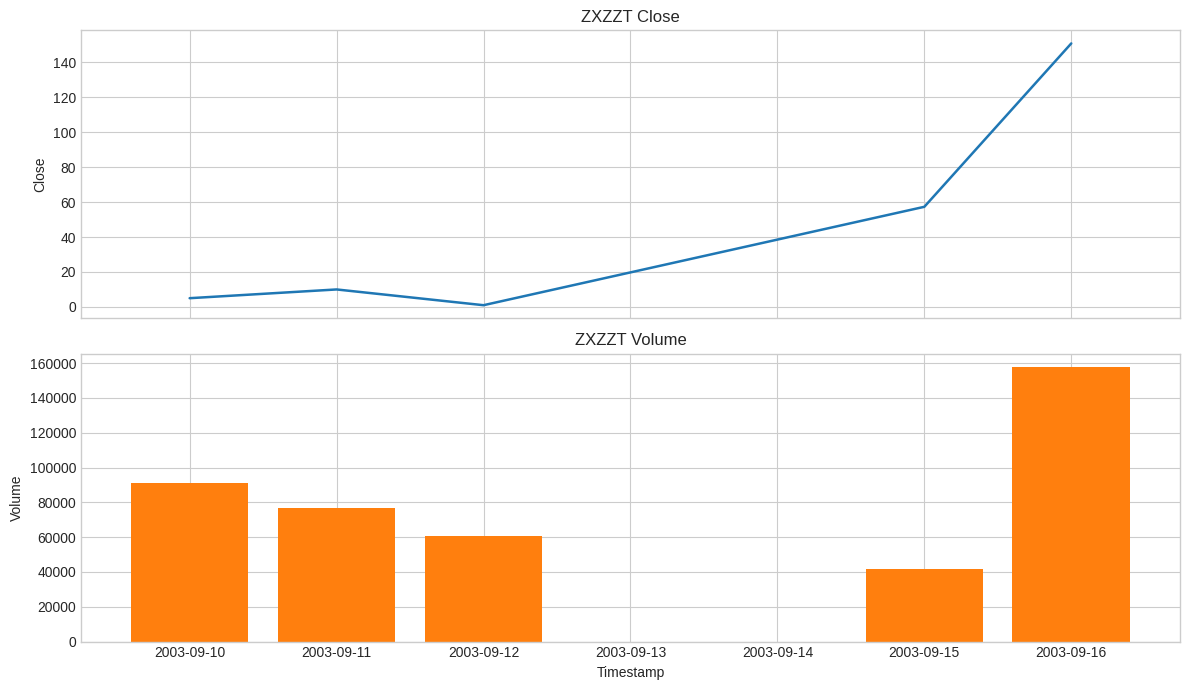

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(symbol_df['timestamp'], symbol_df['close'], color='#1f77b4', linewidth=1.8)
axes[0].set_title(f'{test_symbol} Close')
axes[0].set_ylabel('Close')

axes[1].bar(symbol_df['timestamp'], symbol_df['volume'], color='#ff7f0e', width=0.8)
axes[1].set_title(f'{test_symbol} Volume')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Timestamp')

plt.tight_layout()
plt.show()

## 7. 执行基础数据质量检查

检查空值、重复记录以及价格区间逻辑，确认样本可用于后续因子测试。

In [8]:
quality_report = {
    'null_counts': clean_df[['timestamp', 'instrument', 'open', 'high', 'low', 'close', 'volume']].isna().sum().to_dict(),
    'duplicate_timestamp_instrument': int(clean_df.duplicated(['timestamp', 'instrument']).sum()),
    'high_lt_low': int((clean_df['high'] < clean_df['low']).sum()),
    'open_outside_range': int(((clean_df['open'] < clean_df['low']) | (clean_df['open'] > clean_df['high'])).sum()),
    'close_outside_range': int(((clean_df['close'] < clean_df['low']) | (clean_df['close'] > clean_df['high'])).sum()),
    'non_positive_volume': int((clean_df['volume'] <= 0).sum()),
}
quality_report

{'null_counts': {'timestamp': 0,
  'instrument': 0,
  'open': 0,
  'high': 0,
  'low': 0,
  'close': 0,
  'volume': 0},
 'duplicate_timestamp_instrument': 0,
 'high_lt_low': 0,
 'open_outside_range': 0,
 'close_outside_range': 0,
 'non_positive_volume': 0}

## 8. 统计读取性能与数据规模

记录样本规模、内存占用和文件数量，判断后续是否需要分批读取或更强执行引擎。

In [14]:
memory_mb = clean_df.memory_usage(deep=True).sum() / 1024 / 1024
stats = {
    'parquet_file_count': len(all_files),
    'sample_file_count_used_for_load': len(load_files),
    'sample_rows_loaded': len(clean_df),
    'sample_columns': clean_df.shape[1],
    'sample_memory_mb': round(memory_mb, 3),
    'sample_load_seconds': round(load_elapsed, 4),
}
stats

{'parquet_file_count': 5657,
 'sample_file_count_used_for_load': 20,
 'sample_rows_loaded': 153399,
 'sample_columns': 8,
 'sample_memory_mb': np.float64(17.057),
 'sample_load_seconds': 0.2749}

## 9. 用因子引擎执行一个最小测试

把样本整理成 `timestamp + instrument` 的 MultiIndex `close` 序列，然后运行 `rank(ts_mean(col("close"), 3))`。

In [10]:
from api.columns import col
from api.factor import Factor
from api.operators import rank, ts_mean
from backend.pandas_backend import PandasBackend
from runtime.engine import FactorEngine
from storage.datasource import DataSource


class InMemorySeriesSource(DataSource):
    def __init__(self, data: dict[str, pd.Series]) -> None:
        self.data = data

    def load_column(self, name: str):
        return self.data[name]


close_series = clean_df.set_index(['timestamp', 'instrument'])['close'].sort_index()
factor = Factor(name='smoke_rank_ts_mean_3', expr=rank(ts_mean(col('close'), 3)))
engine = FactorEngine(backend=PandasBackend(), data_source=InMemorySeriesSource({'close': close_series}))
out = engine.run(factor)
result = out['result'].sort_index()

print('analysis =', out['analysis'])
print('result_index_names =', result.index.names)
display(result.groupby(level='instrument').tail(3).rename('factor_value').to_frame())

analysis = AnalysisResult(ir=IRNode(op='rank', inputs=(IRNode(op='ts_mean', inputs=(IRNode(op='column', inputs=(), attrs={'name': 'close'}),), attrs={'window': 3, 'min_periods': None}),), attrs={}), lookback=3, has_ts_op=True, has_cs_op=True, referenced_columns={'close'})
result_index_names = ['timestamp', 'instrument']


factor_value
timestamp  instrument              
2003-09-10 ABANP                NaN
           ABBKP                NaN
           ACIp                 NaN
           ACTp                 NaN
           ADRD                 NaN
...                             ...
2003-09-16 ZTR             0.175765
           ZVXI            0.155854
           ZVZZT           0.999473
           ZWZZT           0.998286
           ZXZZT           0.980881

[23933 rows x 1 columns]

## 10. 用配置文件驱动因子生成与执行

这一节验证最新补上的配置链路：先在项目目录下生成一份临时 YAML 配置，再通过 `FactorEngine.run_from_config(...)` 直接完成数据源构建、表达式解析和因子执行。

In [15]:
import importlib

import runtime.engine as runtime_engine_module
import yaml

runtime_engine_module = importlib.reload(runtime_engine_module)
FactorEngine = runtime_engine_module.FactorEngine

config_path = PROJECT_ROOT / 'examples' / 'notebook_config_smoke.yaml'
config_payload = {
    'factor': {
        'name': 'notebook_rank_ts_mean_3',
        'expr': 'rank(ts_mean(col("close"), 3))',
        'freq': '1d',
        'universe': 'equities',
        'description': 'Notebook config-driven smoke test.',
    },
    'data_source': {
        'type': 'parquet_kline',
        'root': str(DATA_ROOT),
        'instrument_column': 'ticker',
        'timestamp_column': 'window_start',
        'fields': {'close': 'close'},
        'max_files': 20,
    },
    'backend': {'type': 'pandas'},
    'engine': {'enable_cache': True},
}
config_path.write_text(yaml.safe_dump(config_payload, sort_keys=False), encoding='utf-8')

config_out = FactorEngine.run_from_config(config_path)
config_result = config_out['result'].sort_index()

print('config_path =', config_path)
print('factor_name =', config_out['factor'].name)
print('analysis =', config_out['analysis'])
print('result_index_names =', config_result.index.names)
print('non_nan_ratio =', float(config_result.notna().mean()))
display(config_result.dropna().groupby(level='instrument').tail(3).rename('config_factor_value').to_frame().head(15))

config_path = /home/yluel/share/projects/factor_engine/examples/notebook_config_smoke.yaml
factor_name = notebook_rank_ts_mean_3
analysis = AnalysisResult(ir=IRNode(op='rank', inputs=(IRNode(op='ts_mean', inputs=(IRNode(op='column', inputs=(), attrs={'name': 'close'}),), attrs={'window': 3, 'min_periods': None}),), attrs={}), lookback=3, has_ts_op=True, has_cs_op=True, referenced_columns={'close'})
result_index_names = ['timestamp', 'instrument']
non_nan_ratio = 0.892176611320804


config_factor_value
timestamp  instrument                     
2003-09-12 BPC                    0.309157
           BSFpF.CL               0.731138
           CEP                    0.775462
           COE                    0.027720
           GUPpB                  0.685494
           IEM                    0.372586
           IEU                    0.704043
           MTPpA                  0.424135
           NOR                    0.017646
           NORpA                  0.210365
           NORpB                  0.205363
           NORpC                  0.207031
           NORpD                  0.206058
           PIOS                   0.302209
           SANG                   0.617480